# Step 3: Descriptive Statistics Table
### DI 501 Term Project | Eda Yilmaz

**Goal:** Generate descriptive statistics for all four engineered climate stress features, broken down by climate panel.

**Features:**
- `heat_stress_days`: number of days with tmax > 30C in June-July-August
- `cwb_deficit_gs`: absolute sum of negative CWB (prec - ET0) in April-September
- `tavg_jja`: mean daily average temperature in June-July-August
- `prec_gs`: total precipitation (mm) in April-September

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PANELS = ['Mediterranean', 'Temperate', 'Continental']
FEATURES = ['heat_stress_days', 'cwb_deficit_gs', 'tavg_jja', 'prec_gs']
FEATURE_LABELS = {
    'heat_stress_days': 'Heat Stress Days',
    'cwb_deficit_gs':   'CWB Deficit (mm)',
    'tavg_jja':         'Tavg JJA (C)',
    'prec_gs':          'Precip. GS (mm)'
}
PANEL_COLORS = {
    'Mediterranean': '#fde8d8',
    'Temperate':     '#ddeeff',
    'Continental':   '#ddffdd'
}

# Load the ML dataset (2001 onwards, all features available)
df = pd.read_csv('./master_ml_dataset.csv').dropna(subset=FEATURES)

print(f'Total observations: {len(df)}')
print(f'Total regions: {df["adm_id"].nunique()}')
print()
print('Observations per panel:')
print(df['panel'].value_counts().to_string())

Total observations: 10662
Total regions: 671

Observations per panel:
panel
Temperate        5851
Mediterranean    3304
Continental      1507


In [2]:
rows = []
panel_map = {}

for panel in PANELS:
    p = df[df['panel'] == panel]
    for i, f in enumerate(FEATURES):
        rows.append([
            panel if i == 0 else '',
            FEATURE_LABELS[f],
            f'{p[f].mean():.1f}',
            f'{p[f].std():.1f}',
            f'{p[f].min():.1f}',
            f'{p[f].max():.1f}'
        ])
        panel_map[len(rows) - 1] = panel

col_labels = ['Panel', 'Feature', 'Mean', 'Std', 'Min', 'Max']

print('DESCRIPTIVE STATISTICS (all 4 features)')
print()
print(f'{"Panel":<16} {"Feature":<20} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 72)
for row in rows:
    print(f'{row[0]:<16} {row[1]:<20} {row[2]:>8} {row[3]:>8} {row[4]:>8} {row[5]:>8}')

DESCRIPTIVE STATISTICS (all 4 features)

Panel            Feature                  Mean      Std      Min      Max
------------------------------------------------------------------------
Mediterranean    Heat Stress Days         33.3     23.3      0.0     90.0
                 CWB Deficit (mm)        643.2    171.8    128.1   1103.4
                 Tavg JJA (C)             23.0      2.6     12.8     29.0
                 Precip. GS (mm)         368.1    219.8      9.2   1486.7
Temperate        Heat Stress Days          6.7      8.0      0.0     78.0
                 CWB Deficit (mm)        407.1     96.0    150.2    916.3
                 Tavg JJA (C)             18.6      1.5     12.6     26.6
                 Precip. GS (mm)         468.6    144.4     64.0   1262.0
Continental      Heat Stress Days         16.4     13.0      0.0     66.0
                 CWB Deficit (mm)        504.1    102.8    271.9    797.2
                 Tavg JJA (C)             21.0      1.9     16.4     26.

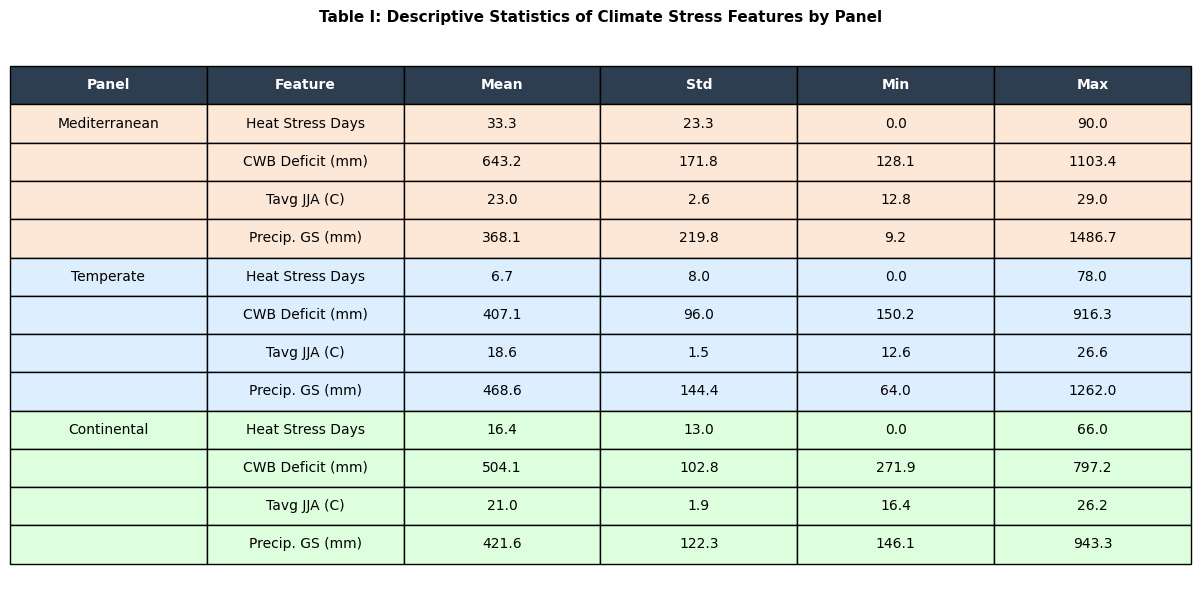

Saved: table_descriptive_stats.png at 300 dpi


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(rows) + 1):
    panel = panel_map[i - 1]
    color = PANEL_COLORS[panel]
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

ax.set_title(
    'Table I: Descriptive Statistics of Climate Stress Features by Panel',
    fontsize=11, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('./table_descriptive_stats.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: table_descriptive_stats.png at 300 dpi')